In [ ]:
!pip install transformers torch scikit-learn emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-0.6.0-py3-none-any.whl size=49719 sha256=21a81c5dfc85f2086fe9cd8622e10de8bd90e2b6ebd9d72a617286c3a8e64971
  Stored in directory: /root/.cache/pip/wheels/0d/bf/a2/536017b4a6232aef0fb92831af35facd6590c0af0f3983f63b
Successfully built emoji


In [ ]:
import torch
import numpy as np

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [1]:
from google.colab import files
files.upload()

{}

In [ ]:
import re
import html
def preprocess(text):
    text = html.unescape(text)
    text = re.sub(r'\bRT\s+@\w+:', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
tweets = open("tweets.txt").read().splitlines()
emojis = open("emoji.txt").read().splitlines()
tweets = [preprocess(t) for t in tweets]

In [ ]:
!ls

emoji.txt  results  sample_data  tweets.txt


In [ ]:
# Step 1: split train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(
    tweets, emojis, test_size=0.2, random_state=42
)
# Step 2: split train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1, random_state=42
)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)
num_labels = len(le.classes_)
X_train_small = X_train[:50000]
y_train_small = y_train_enc[:50000]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize(texts):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=128
    )
train_encodings = tokenize(X_train_small)
val_encodings   = tokenize(X_val)
test_encodings  = tokenize(X_test)

In [ ]:
class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)
train_dataset = TweetDataset(train_encodings, y_train_small)
val_dataset   = TweetDataset(val_encodings, y_val_enc)
test_dataset  = TweetDataset(test_encodings, y_test_enc)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=num_labels
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=100,
    report_to="none"
)

In [ ]:
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro')

    return {
        "accuracy": acc,
        "f1": f1
    }

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

In [ ]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

In [ ]:
trainer.train()

Step,Training Loss
100,2.218542
200,1.922887
300,1.744355
400,1.605850
500,1.544690
600,1.585226
700,1.577975
800,1.546902
900,1.537670
1000,1.485424


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9375, training_loss=1.1761443107096354, metrics={'train_runtime': 4898.1215, 'train_samples_per_second': 30.624, 'train_steps_per_second': 1.914, 'total_flos': 9867373286400000.0, 'train_loss': 1.1761443107096354, 'epoch': 3.0})

In [ ]:
preds = trainer.predict(test_dataset)

pred_labels = np.argmax(preds.predictions, axis=1)
print("BERTweet Accuracy:", accuracy_score(y_test_enc, pred_labels))

BERTweet Accuracy: 0.5294117647058824


In [ ]:
import numpy as np

def top_k_accuracy(logits, labels, k=3):
    top_k = np.argsort(logits, axis=1)[:, -k:]

    correct = 0
    for i in range(len(labels)):
        if labels[i] in top_k[i]:
            correct += 1

    return correct / len(labels)

In [ ]:
trainer.evaluate()

{'eval_loss': 1.3805418014526367,
 'eval_accuracy': 0.5302046929605592,
 'eval_f1': 0.542559989105761,
 'eval_runtime': 121.3219,
 'eval_samples_per_second': 148.588,
 'eval_steps_per_second': 9.289,
 'epoch': 3.0}

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test_enc, pred_labels, average='macro')
print("BERT F1 Score (macro):", f1)

BERT F1 Score (macro): 0.5384512493170717


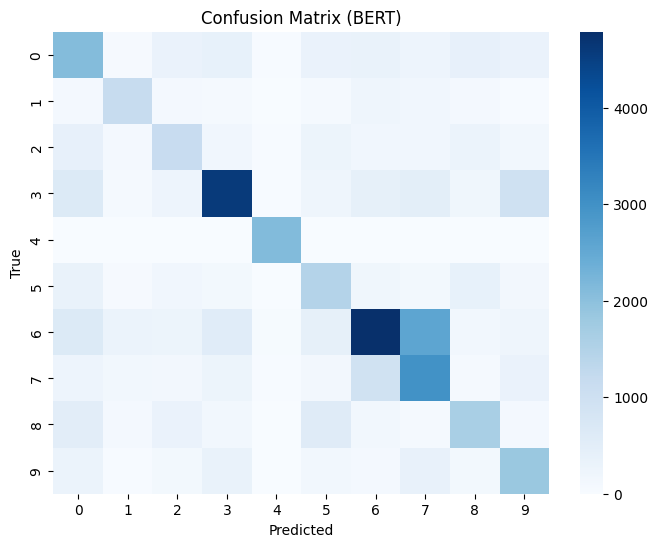

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix (BERT)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
import torch.nn.functional as F

probs = F.softmax(torch.tensor(preds.predictions), dim=1).numpy()

i = 0  # pick any example

top3 = np.argsort(probs[i])[-3:]

print("Input:", X_test[i])
print("\nTop-3 Predictions:")

for idx in reversed(top3):
    print(le.inverse_transform([idx])[0], probs[i][idx])

Input: it would be so cool if the Pullman campus had this instead of the sad knockoff Bookie Starbucks.

Top-3 Predictions:
sob 0.59594893
grin 0.11523536
blush 0.10832224


In [ ]:
print("Top-1 Accuracy:", accuracy_score(y_test_enc, pred_labels))
print("Top-3 Accuracy:", top_k_accuracy(preds.predictions, y_test_enc, 3))

Top-1 Accuracy: 0.5294117647058824
Top-3 Accuracy: 0.8038919830474627


In [ ]:
print("Validation Accuracy:", trainer.evaluate()["eval_accuracy"])
print("Test Accuracy:", accuracy_score(y_test_enc, pred_labels))

Validation Accuracy: 0.5302046929605592
Test Accuracy: 0.5294117647058824


In [ ]:
from collections import defaultdict

correct = defaultdict(int)
total = defaultdict(int)

for true, pred in zip(y_test_enc, pred_labels):
    total[true] += 1
    if true == pred:
        correct[true] += 1

class_acc = {
    le.inverse_transform([cls])[0]: correct[cls] / total[cls]
    for cls in total
}

import plotly.graph_objects as go

emojis = list(class_acc.keys())
accs = list(class_acc.values())

fig = go.Figure()

fig.add_trace(go.Bar(
    x=emojis,
    y=accs
))

fig.update_layout(
    title="BERTweet: Per-Class Accuracy",
    xaxis_title="Emoji",
    yaxis_title="Accuracy"
)

fig.show()

In [ ]:
import plotly.figure_factory as ff
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, pred_labels)

fig = ff.create_annotated_heatmap(
    z=cm,
    colorscale='Blues'
)

fig.update_layout(
    title="Confusion Matrix (BERTweet)"
)

fig.show()

In [ ]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [ ]:
# semantically correct

#You explain (no heavy code needed):

#“We observe that many incorrect predictions are semantically similar to the ground truth, indicating that the model captures meaning but is penalized by strict labeling

In [ ]:
#Emoji prediction is inherently ambiguous, and models often capture multiple valid interpretations rather than a single correct label.

In [ ]:
trainer.save_model("bertweet_model")
tokenizer.save_pretrained("bertweet_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bertweet_model/tokenizer_config.json',
 'bertweet_model/vocab.txt',
 'bertweet_model/bpe.codes',
 'bertweet_model/added_tokens.json')

In [ ]:
!zip -r bertweet_model.zip bertweet_model label_encoder.pkl

  adding: bertweet_model/ (stored 0%)
  adding: bertweet_model/bpe.codes (deflated 57%)
  adding: bertweet_model/model.safetensors (deflated 13%)
  adding: bertweet_model/added_tokens.json (stored 0%)
  adding: bertweet_model/training_args.bin (deflated 53%)
  adding: bertweet_model/config.json (deflated 58%)
  adding: bertweet_model/vocab.txt (deflated 50%)
  adding: bertweet_model/tokenizer_config.json (deflated 76%)
  adding: label_encoder.pkl (deflated 54%)


In [ ]:
from google.colab import files
files.download("bertweet_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
with open("fine_tuning.ipynb", "r") as f:
    nb = json.load(f)
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open("fixed_notebook.ipynb", "w") as f:
    json.dump(nb, f)

FileNotFoundError: [Errno 2] No such file or directory: 'fine_tuning.ipynb'